# 1. Project Overview

## 1.1 Introduction

This project analyses coffee vending machine transaction data to understand customer purchasing patterns and explore whether machine learning can predict the type of coffee purchased. The dataset contains **2,838 transaction records** with information including the transaction date and time, payment method, card identifier, amount spent, and coffee product purchased.

The analysis begins with data exploration and visualisation to identify patterns in sales and customer preferences. The project then applies a machine learning approach using a **Random Forest Classifier** to predict the coffe_name based on transaction-related features.

## 1.2 Problem Statement

Coffee vending machine operators need to understand which products customers are most likely to purchase and how transaction characteristics relate to product choice. However, manually analysing thousands of transactions can make it difficult to identify meaningful patterns.

The problem addressed in this project is therefore to analyse historical coffee sales data and develop a classification model that can predict the type of coffee purchased using available transaction features such as payment information, purchase amount, and time-related variables.

## 1.3 Purpose of the Project

The purpose of this project is to:

- Explore and understand the characteristics and patterns in the coffee sales dataset.
- Identify the most popular coffee products based on sales activity and revenue.
- Examine transaction features such as payment method, purchase amount, date, and time.
- Prepare the data for machine learning through feature engineering and preprocessing.
- Develop and evaluate a Random Forest classification model to predict the coffee product purchased.
- Generate insights that can support inventory planning, product management, and future sales analysis.


##### Import necessary libraries

In [226]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


#### Load Data

In [227]:
sales_data = pd.read_csv('index.csv')

In [228]:
sales_data

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte
...,...,...,...,...,...,...
2833,2025-01-22,2025-01-22 18:49:59.374,card,ANON-0000-0000-1119,35.76,Cocoa
2834,2025-01-22,2025-01-22 19:10:26.039,card,ANON-0000-0000-1051,30.86,Americano with Milk
2835,2025-01-22,2025-01-22 19:11:23.124,card,ANON-0000-0000-1051,35.76,Cappuccino
2836,2025-01-22,2025-01-22 19:29:15.703,card,ANON-0000-0000-1120,35.76,Latte


# Display the first few rows
# Get info about data types and missing values
# Get statistical summary of numerical columns


In [229]:
print(sales_data.head())        
print(sales_data.info())        
print(sales_data.describe())    

         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2838 non-null   object 
 1   datetime     2838 non-null   object 
 2   cash_type    2838 non-null   object 
 3   card         2749 non-null   object 
 4   money        2838 non-null   float64
 5   

In [230]:
# Count missing_values rows
sales_data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

### Since card is categorical, replace missing values with the most frequent value.

In [231]:
sales_data['card'] = sales_data['card'].fillna(
    sales_data['card'].mode()[0]
)

In [232]:
print(sales_data.isnull().sum())

date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64


### Convert datetime into useful features.

In [233]:
sales_data['datetime'] = pd.to_datetime(sales_data['datetime'])

sales_data['hour'] = sales_data['datetime'].dt.hour
sales_data['day'] = sales_data['datetime'].dt.day
sales_data['month'] = sales_data['datetime'].dt.month

In [234]:
sales_data

,date,datetime,cash_type,card,money,coffee_name,hour,day,month
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.70,Latte,10,1,3
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.70,Hot Chocolate,12,1,3
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.70,Hot Chocolate,12,1,3
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.90,Americano,13,1,3
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.70,Latte,13,1,3
...,...,...,...,...,...,...,...,...,...
2833,2025-01-22,2025-01-22 18:49:59.374,card,ANON-0000-0000-1119,35.76,Cocoa,18,22,1
2834,2025-01-22,2025-01-22 19:10:26.039,card,ANON-0000-0000-1051,30.86,Americano with Milk,19,22,1
2835,2025-01-22,2025-01-22 19:11:23.124,card,ANON-0000-0000-1051,35.76,Cappuccino,19,22,1
2836,2025-01-22,2025-01-22 19:29:15.703,card,ANON-0000-0000-1120,35.76,Latte,19,22,1


# Extract date for daily sales trend

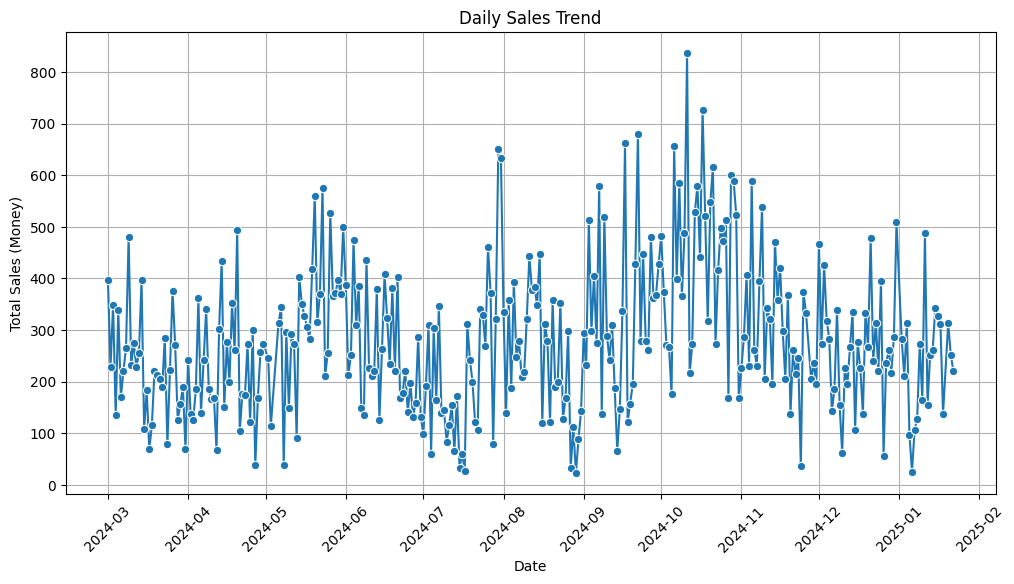

In [235]:

sales_data['date'] = pd.to_datetime(sales_data['date'])

# Aggregate daily sales
daily_sales = sales_data.groupby('date')['money'].sum().reset_index()

# Plot daily sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='money', data=daily_sales, marker='o')
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales (Money)')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


### Total sales per coffee type

C:\Users\user\AppData\Local\Temp\ipykernel_34168\3797338908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='money', y='coffee_name', data=coffee_sales, palette='viridis')


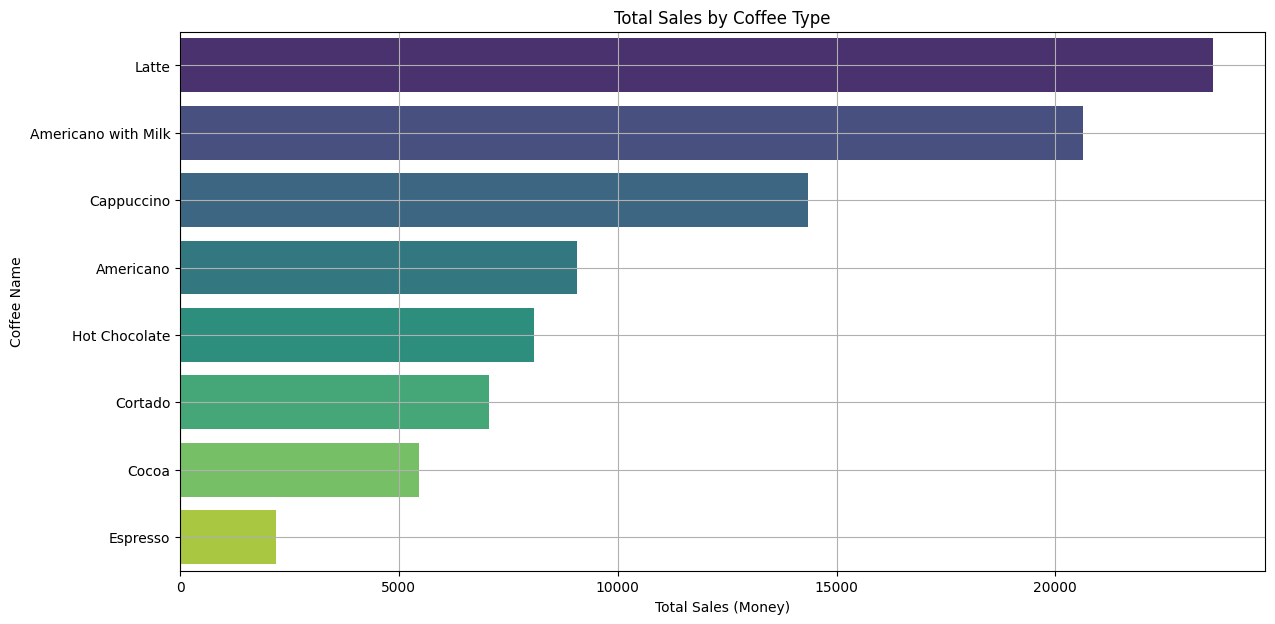

In [236]:

coffee_sales = sales_data.groupby('coffee_name')['money'].sum().reset_index().sort_values(by='money', ascending=False)

# Bar plot for sales by coffee type
plt.figure(figsize=(14, 7))
sns.barplot(x='money', y='coffee_name', data=coffee_sales, palette='viridis')
plt.title('Total Sales by Coffee Type')
plt.xlabel('Total Sales (Money)')
plt.ylabel('Coffee Name')
plt.grid(True)
plt.show()


### Distribution plot for money spent

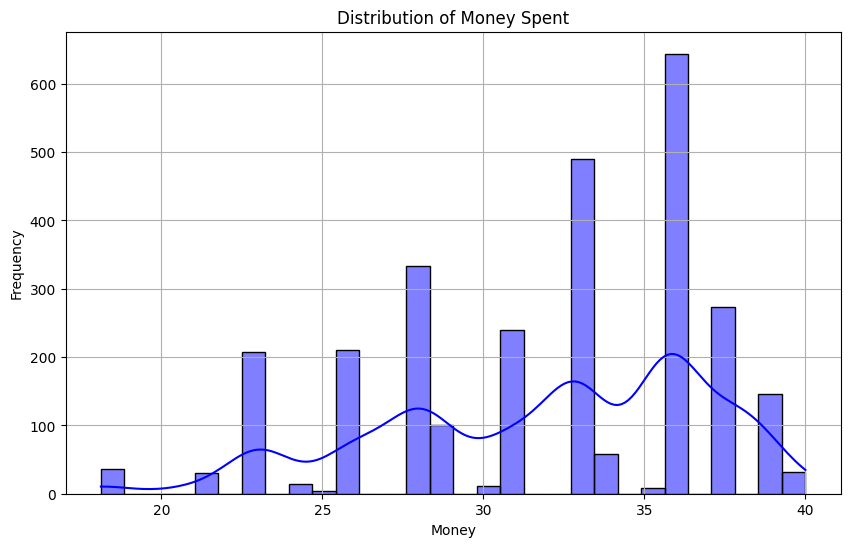

In [237]:

plt.figure(figsize=(10, 6))
sns.histplot(sales_data['money'], bins=30, kde=True, color='blue')
plt.title('Distribution of Money Spent')
plt.xlabel('Money')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


### Define Features and Target

In [238]:
X = sales_data.drop('coffee_name', axis=1)
y = sales_data['coffee_name']

### Encode target variable

In [239]:
le = LabelEncoder()

y = le.fit_transform(y)

### Split Dataset

In [240]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Preprocessing
### Categorical columns

In [241]:
categorical_cols = ['cash_type', 'card']
numeric_cols = ['money', 'hour', 'day', 'month']

### Create preprocessing pipeline

In [242]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_cols
        ),
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_cols
        )
    ]
)

### Train Model
### Random Forest is a good classification model for this dataset

In [243]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cash_type', 'card']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['money', 'hour', 'day',
                                                   'month'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

### Make Predictions

In [244]:
y_pred = model.predict(X_test)

### Evaluate Model

In [245]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.727112676056338

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.88      0.80        69
           1       0.98      0.99      0.99       135
           2       0.61      0.38      0.47        80
           3       0.59      0.43      0.50        30
           4       0.85      0.62      0.72        55
           5       0.95      0.86      0.90        21
           6       0.53      0.38      0.44        45
           7       0.57      0.80      0.67       133

    accuracy                           0.73       568
   macro avg       0.73      0.67      0.68       568
weighted avg       0.73      0.73      0.72       568



# 2. Conclusion and Key Insights

The analysis of the coffee vending machine dataset provides useful insights into customer purchasing behaviour and product performance. The dataset contains **2,838 transactions** across **eight coffee product categories**, with total recorded sales of approximately **90,496.60** in the dataset's monetary units.

A key insight is that customer demand is not evenly distributed across the available products. **Latte** generated the highest total sales, followed by **Americano with Milk** and **Cappuccino**, while **Espresso** generated the lowest total sales. This indicates that milk-based coffee products are particularly important to the overall sales performance of the vending machine.

The payment data also shows a strong preference for card transactions. Of the 2,838 transactions, **2,749 were card payments**, compared with only **89 cash payments**. This suggests that the vending machine is primarily used through cashless payment methods.

The machine learning model was developed using a preprocessing pipeline that handled categorical and numerical variables before applying a Random Forest Classifier. The final model achieved an accuracy of approximately **72.7%** on the test data. This demonstrates that the available transaction features contain useful information for predicting the coffee product purchased, although prediction performance varies across the different coffee categories.

Overall, the project demonstrates how exploratory data analysis and machine learning can be combined to transform raw transaction data into meaningful business insights. The model provides a useful baseline for predicting customer product choices, while the exploratory analysis highlights the products and payment behaviours that contribute most significantly to sales.

# 3. Recommendations

Based on the analysis and modelling results, the following recommendations are proposed:

1. **Prioritise high-performing products:** Maintain sufficient inventory for Latte, Americano with Milk, and Cappuccino, as these products contribute strongly to total sales.

2. **Review low-performing products:** Investigate whether products such as Espresso and Cocoa require promotional strategies, pricing adjustments, or changes to their availability.

3. **Support cashless payments:** Since the majority of transactions are made using cards, the reliability and usability of card payment systems should remain a priority.

4. **Improve the predictive model:** Future versions of the model could include additional features such as day of the week, seasonality, customer purchase history, promotional information, and machine location. These variables may improve the model's ability to distinguish between similar coffee preferences.

5. **Address class-specific performance:** The classification report shows that some coffee categories are predicted more accurately than others. Future work should investigate class imbalance, feature importance, and alternative algorithms to improve performance for the weaker classes.

6. **Extend the analysis to forecasting:** The transaction data could also be used to build time-series or regression models to forecast future daily, weekly, or monthly sales. This would support inventory management and operational planning.

7. **Monitor the model over time:** As new transaction data becomes available, the model should be retrained and evaluated regularly to ensure that it continues to reflect current customer purchasing behaviour.